In [ ]:
# Unpickling the files
import pickle
with open('/content/images.p','rb') as f:  #rb - read in binary
  images = pickle.load(f)

with open('/content/labels.p','rb') as f:
  labels = pickle.load(f)

In [ ]:
print(images.shape)
print(labels.shape)

(292, 100, 100)
(292,)


In [ ]:
labels

array(['aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'aditya',
       'aditya', 'aditya', 'aditya', 'aditya', 'aditya', 'adit

In [ ]:
set(labels) # to check the unique values present in labels

{np.str_('aditya'), np.str_('hitesh'), np.str_('suvajeet')}

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)

In [ ]:
set(labels)

{np.int64(0), np.int64(1), np.int64(2)}

In [ ]:
le.inverse_transform([0,1,2])

array(['aditya', 'hitesh', 'suvajeet'], dtype='<U8')

In [ ]:
p = len(set(labels))
print("Total Number of Persons: ",p)

Total Number of Persons:  3


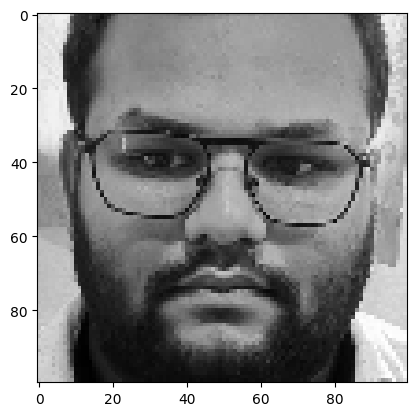

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(images[177],cmap='gray')
plt.show()

In [ ]:
import cv2

In [ ]:
def preprocessing(img):
  img =  cv2.equalizeHist(img)  #to increase the contrast of the image
  img = img.reshape(100,100,1)   # reshaped the img to 100*100  and channel 1(for B/W)
  img = img/255                  #to standardise the image
  return img

In [ ]:
# Now we have to apply this function on each image so first we'll use 'map function' to
# Now to unpack the values we need to cinvert it into list
# And as we know that imgs are stored un the form of array so we'll convert it into an array
import numpy as np

images = np.array(list(map(preprocessing,images)))
print("Shape of input :",images.shape)

Shape of input : (292, 100, 100, 1)


In [ ]:
#to_categorical
from keras.utils import to_categorical
labels = to_categorical(labels)

In [ ]:
#Model Training
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

from keras.layers import Conv2D,MaxPooling2D,Flatten

In [ ]:
def Lenet_Model():
  model = Sequential()
  #Convolution & ReLU layer
  model.add(Conv2D(30,(5,5),input_shape=(100,100,1),activation='relu'))
  #Pooling Layer
  model.add(MaxPooling2D(pool_size=(2,2)))

  #Convolution & ReLU layer
  model.add(Conv2D(15,(3,3),activation='relu'))
  #MaxPooling Layer
  model.add(MaxPooling2D(pool_size=(2,2)))

  #Flatten Layer
  model.add(Flatten())

  #Hidden layers
  model.add(Dense(50, activation='relu'))
  #output layer
  model.add(Dense(p, activation='softmax'))
  model.compile(Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [ ]:
model=Lenet_Model()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 30)     │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 46, 46, 15)     │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 15)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 7935)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │       396,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,798 (1.53 MB)

 Trainable params: 401,798 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(images,labels,validation_split=0.1,epochs=20)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 345ms/step - accuracy: 1.0000 - loss: 1.0928e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step - accuracy: 1.0000 - loss: 6.1720e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 1.0000 - loss: 5.9459e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 1.0000 - loss: 7.3553e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 1.0000 - loss: 5.0145e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step - accuracy: 1.0000 - loss: 8.8267e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 253ms/step - accuracy: 1.0000 - loss: 7.1557e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 

In [ ]:
# to save the model
# ".h5" file extension is use to store keras model
model.save('final_model.h5')